In [2]:
import pandas as pd

df = pd.read_excel("Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.shape

(541909, 8)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [5]:
df = df.dropna(subset=["CustomerID"])

df.shape

(406829, 8)

In [6]:
(df["Quantity"] < 0).sum()

np.int64(8905)

In [7]:
df = df[df["Quantity"] > 0]

df.shape

(397924, 8)

In [8]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [9]:
customer_data = (
    df.groupby("CustomerID")
      .agg(
          Total_Revenue=("Revenue", "sum"),
          Total_Quantity=("Quantity", "sum"),
          Number_of_Orders=("InvoiceNo", "nunique")
      )
)

customer_data.head()

,Total_Revenue,Total_Quantity,Number_of_Orders
CustomerID,,,
12346.0,77183.60,74215,1
12347.0,4310.00,2458,7
12348.0,1797.24,2341,4
12349.0,1757.55,631,1
12350.0,334.40,197,1


In [12]:
from sklearn.preprocessing import StandardScaler

features = customer_data[
    ["Total_Revenue", "Total_Quantity", "Number_of_Orders"]
]

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

scaled_features[:5]

array([[ 8.35963391, 14.44520088, -0.42467487],
       [ 0.25104636,  0.25000604,  0.35408019],
       [-0.02854645,  0.22686074, -0.03529734],
       [-0.03296273, -0.11141683, -0.42467487],
       [-0.19131549, -0.19727207, -0.42467487]])

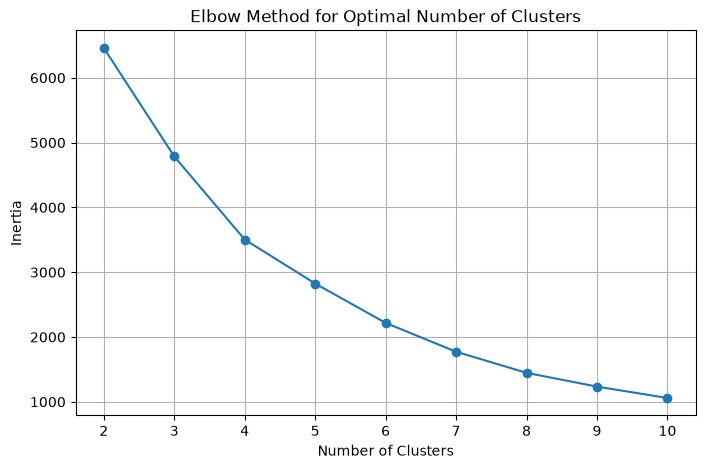

In [13]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker="o")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

In [14]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, labels)
    silhouette_scores.append(score)

for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K={k}: Silhouette Score={score:.3f}")

K=2: Silhouette Score=0.962
K=3: Silhouette Score=0.927
K=4: Silhouette Score=0.767
K=5: Silhouette Score=0.764
K=6: Silhouette Score=0.768
K=7: Silhouette Score=0.674
K=8: Silhouette Score=0.665
K=9: Silhouette Score=0.653
K=10: Silhouette Score=0.657


In [15]:
for k in [2, 3, 4]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_features)

    temp_data = customer_data.copy()
    temp_data["Cluster"] = labels

    print(f"\n===== K = {k} =====")
    print("Customers per cluster:")
    print(temp_data["Cluster"].value_counts().sort_index())

    print("\nCluster averages:")
    print(
        temp_data.groupby("Cluster")[
            ["Total_Revenue", "Total_Quantity", "Number_of_Orders"]
        ].mean().round(2)
    )


===== K = 2 =====
Customers per cluster:
Cluster
0    4320
1      19
Name: count, dtype: int64

Cluster averages:
         Total_Revenue  Total_Quantity  Number_of_Orders
Cluster                                                 
0              1593.19          931.62              3.99
1            106781.41        60900.32             67.95

===== K = 3 =====
Customers per cluster:
Cluster
0    4296
1       7
2      36
Name: count, dtype: int64

Cluster averages:
         Total_Revenue  Total_Quantity  Number_of_Orders
Cluster                                                 
0              1439.95          840.53              3.80
1            184143.69        89810.71             65.57
2             39899.28        26169.69             48.53

===== K = 4 =====
Customers per cluster:
Cluster
0    3964
1       6
2      24
3     345
Name: count, dtype: int64

Cluster averages:
         Total_Revenue  Total_Quantity  Number_of_Orders
Cluster                                                

In [16]:
for k in [3, 4]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_features)

    temp_data = customer_data.copy()
    temp_data["Cluster"] = labels

    summary = temp_data.groupby("Cluster").agg(
        Customers=("Cluster", "size"),
        Avg_Revenue=("Total_Revenue", "mean"),
        Avg_Quantity=("Total_Quantity", "mean"),
        Avg_Orders=("Number_of_Orders", "mean")
    ).round(2)

    print(f"\n===== K = {k} =====")
    print(summary)


===== K = 3 =====
         Customers  Avg_Revenue  Avg_Quantity  Avg_Orders
Cluster                                                  
0             4296      1439.95        840.53        3.80
1                7    184143.69      89810.71       65.57
2               36     39899.28      26169.69       48.53

===== K = 4 =====
         Customers  Avg_Revenue  Avg_Quantity  Avg_Orders
Cluster                                                  
0             3964       982.81        591.36        2.81
1                6    195271.03      95131.67       67.33
2               24     51652.50      34592.04       57.42
3              345      7548.54       4163.91       16.30


In [17]:
final_kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

customer_data["Cluster"] = final_kmeans.fit_predict(scaled_features)

customer_data.head()

,Total_Revenue,Total_Quantity,Number_of_Orders,Cluster
CustomerID,,,,
12346.0,77183.60,74215,1,2
12347.0,4310.00,2458,7,0
12348.0,1797.24,2341,4,0
12349.0,1757.55,631,1,0
12350.0,334.40,197,1,0


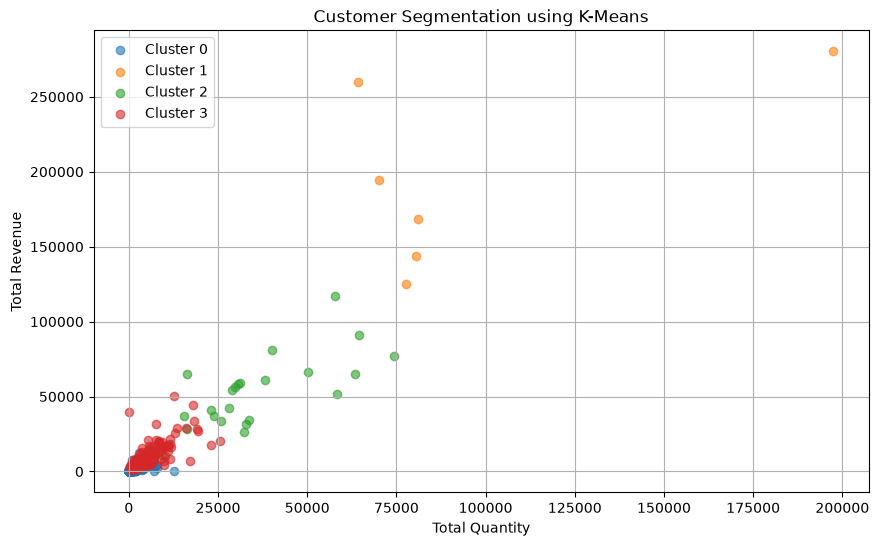

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for cluster in sorted(customer_data["Cluster"].unique()):
    cluster_data = customer_data[customer_data["Cluster"] == cluster]
    
    plt.scatter(
        cluster_data["Total_Quantity"],
        cluster_data["Total_Revenue"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.xlabel("Total Quantity")
plt.ylabel("Total Revenue")
plt.title("Customer Segmentation using K-Means")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
segment_summary = customer_data.groupby("Cluster").agg(
    Customers=("Cluster", "count"),
    Avg_Revenue=("Total_Revenue", "mean"),
    Avg_Quantity=("Total_Quantity", "mean"),
    Avg_Orders=("Number_of_Orders", "mean")
).round(2)

segment_summary

,Customers,Avg_Revenue,Avg_Quantity,Avg_Orders
Cluster,,,,
0,3964,982.81,591.36,2.81
1,6,195271.03,95131.67,67.33
2,24,51652.50,34592.04,57.42
3,345,7548.54,4163.91,16.30


## Customer Segmentation Insights

The K-Means clustering analysis identified four distinct customer segments based on total revenue, total quantity purchased, and number of orders.

- **Cluster 0 – Low-Value Customers:** The largest segment with 3,964 customers. These customers have relatively low revenue and fewer orders.
- **Cluster 3 – Regular Customers:** 345 customers with higher purchasing activity and order frequency.
- **Cluster 2 – High-Value Customers:** 24 customers with significantly higher revenue, quantity purchased, and number of orders.
- **Cluster 1 – VIP Customers:** Only 6 customers, but they show exceptionally high purchasing activity and revenue.

### Business Recommendations

1. Provide personalized offers and promotions to low-value customers to encourage repeat purchases.
2. Reward regular customers with loyalty benefits to increase retention.
3. Give high-value customers exclusive offers and personalized services.
4. Maintain strong relationships with VIP customers because they contribute substantial revenue.
5. Use customer segmentation to design different marketing strategies for each customer group.